### Imports

In [55]:
import sys
import subprocess
import importlib

def _ensure(package_name: str, import_name: str = None):
    """
    Ensure a package is importable. If not present, install with pip.
    package_name: name to pass to pip (e.g. "scikit-learn")
    import_name: module name to import (e.g. "sklearn"). If None, use package_name.
    """
    mod_name = import_name or package_name
    try:
        importlib.import_module(mod_name)
        return False
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        importlib.import_module(mod_name)
        return True

_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "nltk": "nltk",
    "openpyxl": "openpyxl",
    "gensim": "gensim",
    "statsmodels": "statsmodels",
    "xgboost": "xgboost",
}

_installed = {}
for module_name, pip_name in _packages.items():
    _installed[module_name] = _ensure(pip_name, module_name)


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from gensim.models import Word2Vec

from xgboost import XGBClassifier

import re

# Download required NLTK resources (quiet)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

True

### Helper Functions

In [56]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str, remove_stopwords: bool = True) -> str:
    # Normalize whitespace and lowercase
    s = " ".join(str(text).split()).lower()

    # Remove URLs & email/user mentions
    s = re.sub(r'http\S+|www\S+|@\S+', '', s)

    # Remove special characters, punctuation, and numbers (keep letters and spaces)
    s = re.sub(r'[^a-zA-Z\s]', ' ', s)

    # Tokenize
    tokens = word_tokenize(s)

    # Remove stopwords & lemmatize (or just lemmatize if remove_stopwords=False)
    if remove_stopwords:
        tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

def load_lf_xlsx(xlsx_path: str) -> pd.DataFrame:
    xl = pd.read_excel(xlsx_path)
    
    X = xl.drop(columns=['label'])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lf = pd.DataFrame(X_scaled, columns=X.columns)

    return lf.reset_index(drop=True) 

### Datasets

#### Dataset Loader

In [57]:
def load_dataset(csv_path: str, lf_path: str):
    df = pd.read_csv(csv_path)

    # taking only text and label columns, dropping rows with missing values
    df = df[["text", "label"]].dropna()

    # Preprocess text: normalize, remove stopwords, lemmatize
    df["clean_text"] = df["text"].map(lambda s: preprocess(s, remove_stopwords=True))

    # Tokenized sentences
    tokenized_sentences = df["clean_text"].apply(lambda x: x.split())

    # Labels
    y = df["label"].astype(int)

    # Linguistic features
    lf = load_lf_xlsx(lf_path)

    # Drop original label columns
    df = df.drop(columns=["label"])

    return {
        "tokenized_sentences": tokenized_sentences,
        "dataset": df,
        "output_labels": y,
        "linguistic_features": lf
    }

In [58]:
def create_train_test_split(X_data, y_data, random_state=42, test_size = 0.3):
    return train_test_split(X_data, y_data, test_size=test_size, random_state=random_state)

#### Mcintire Dataset

In [59]:
mcinter_dataset_path = "Dataset/Mcintire_DataSet.csv"
mcinter_lf_path = "Dataset/linguistic_features/arrays_Mcintire.xlsx"

mcinter_data = load_dataset(mcinter_dataset_path, mcinter_lf_path)

mcinter_df = mcinter_data["dataset"]
mcinter_y = mcinter_data["output_labels"]
mcinter_lf = mcinter_data["linguistic_features"]
mcinter_tokenized = mcinter_data["tokenized_sentences"]

mcinter_df.shape, mcinter_y.shape, mcinter_lf.shape, mcinter_tokenized.shape

((6335, 2), (6335,), (6335, 80), (6335,))

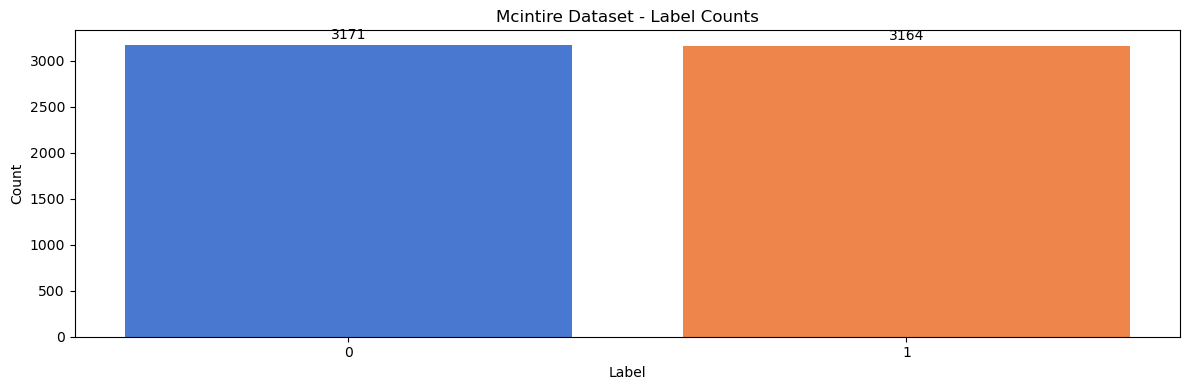

In [60]:
counts = mcinter_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Mcintire Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [61]:
# Word2Vec model training and embedding extraction

mcinter_word2vec = Word2Vec(sentences=mcinter_tokenized, vector_size=100, window=5, min_count=1, workers=4)

mcinter_word_embeddings = np.array([np.mean([mcinter_word2vec.wv[word] for word in words if word in mcinter_word2vec.wv] or [np.zeros(100)], axis=0) for words in mcinter_tokenized])

In [62]:
# train-test split with combined features

X_combined = np.concatenate((mcinter_word_embeddings, mcinter_lf.values), axis=1)

X_train, X_test, y_train, y_test = create_train_test_split(X_combined, mcinter_y, random_state=42, test_size=0.3)

In [63]:
# checking the dimensions and potential issues
print(f"Word embeddings shape: {mcinter_word_embeddings.shape}")
print(f"Linguistic features shape: {mcinter_lf.shape}")
print(f"Combined features shape: {X_combined.shape}")
print(f"Training samples: {len(y_train)}")
print(f"Total features: {X_combined.shape[1]}")
print(f"Features vs Samples ratio: {X_combined.shape[1] / len(y_train):.2f}")

# Check for potential issues
print("\nChecking for potential multicollinearity issues:")
print(f"Any NaN values: {np.isnan(X_combined).any()}")
print(f"Any infinite values: {np.isinf(X_combined).any()}")

# Check feature variance
feature_variances = np.var(X_combined, axis=0)
low_variance_features = np.sum(feature_variances < 1e-10)
print(f"Features with very low variance (< 1e-10): {low_variance_features}")

# Check condition number (indicates multicollinearity)
try:
    cond_number = np.linalg.cond(X_combined)
    print(f"Condition number: {cond_number:.2e}")
    if cond_number > 1e12:
        print("High condition number suggests severe multicollinearity")
except:
    print("Could not compute condition number - likely singular matrix")

Word embeddings shape: (6335, 100)
Linguistic features shape: (6335, 80)
Combined features shape: (6335, 180)
Training samples: 4434
Total features: 180
Features vs Samples ratio: 0.04

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 2.63e+18
High condition number suggests severe multicollinearity


##### Logistic Regression

In [64]:
mcinter_logit_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
mcinter_logit_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [65]:
y_pred = mcinter_logit_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9353

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       933
           1       0.94      0.93      0.94       968

    accuracy                           0.94      1901
   macro avg       0.94      0.94      0.94      1901
weighted avg       0.94      0.94      0.94      1901



##### SVM

In [66]:
mcinter_svm_model = SVC(gamma='auto')
mcinter_svm_model.fit(X_train, y_train)

SVC(gamma='auto')

In [67]:
y_pred = mcinter_svm_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report SVM:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9337

Classification Report SVM:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       933
           1       0.93      0.95      0.94       968

    accuracy                           0.93      1901
   macro avg       0.93      0.93      0.93      1901
weighted avg       0.93      0.93      0.93      1901



##### XGBoost

In [68]:
mcinter_xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
mcinter_xgb_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:47:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [69]:
y_pred = mcinter_xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9500

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       933
           1       0.95      0.96      0.95       968

    accuracy                           0.95      1901
   macro avg       0.95      0.95      0.95      1901
weighted avg       0.95      0.95      0.95      1901



#### Kaggle Dataset

In [70]:
kaggle_dataset_path = "Dataset/Kaggle.csv"
kaggle_lf_path = "Dataset/linguistic_features/arrays_kaggle.xlsx"

kaggle_data = load_dataset(kaggle_dataset_path, kaggle_lf_path)

kaggle_df = kaggle_data["dataset"]
kaggle_y = kaggle_data["output_labels"]
kaggle_lf = kaggle_data["linguistic_features"]
kaggle_tokenized = kaggle_data["tokenized_sentences"]

kaggle_df.shape, kaggle_y.shape, kaggle_lf.shape, kaggle_tokenized.shape

((20761, 2), (20761,), (20761, 80), (20761,))

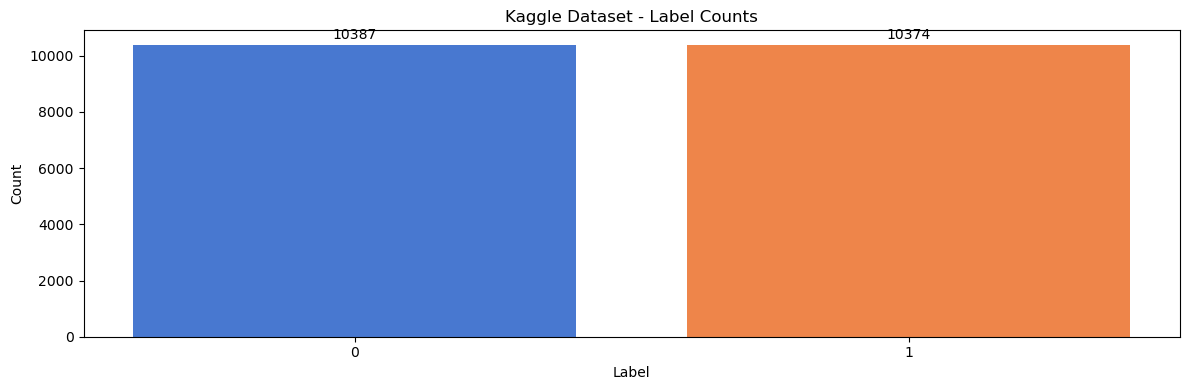

In [71]:
counts = kaggle_y.value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

# Bar plot
colors = sns.color_palette("muted", n_colors=len(counts))
ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.set_title("Kaggle Dataset - Label Counts")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.max() * 0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [72]:
# Word2Vec model training and embedding extraction
kaggle_word2vec = Word2Vec(sentences=kaggle_tokenized, vector_size=100, window=5, min_count=1, workers=4)

kaggle_word_embeddings = np.array([np.mean([kaggle_word2vec.wv[word] for word in words if word in kaggle_word2vec.wv] or [np.zeros(100)], axis=0) for words in kaggle_tokenized])

In [73]:
# train-test split with combined features

X_combined = np.concatenate((kaggle_word_embeddings, kaggle_lf.values), axis=1)

X_train, X_test, y_train, y_test = create_train_test_split(X_combined, kaggle_y, random_state=42, test_size=0.3)

In [74]:
# checking the dimensions and potential issues
print(f"Word embeddings shape: {kaggle_word_embeddings.shape}")
print(f"Linguistic features shape: {kaggle_lf.shape}")
print(f"Combined features shape: {X_combined.shape}")
print(f"Training samples: {len(y_train)}")
print(f"Total features: {X_combined.shape[1]}")
print(f"Features vs Samples ratio: {X_combined.shape[1] / len(y_train):.2f}")

# Check for potential issues
print("\nChecking for potential multicollinearity issues:")
print(f"Any NaN values: {np.isnan(X_combined).any()}")
print(f"Any infinite values: {np.isinf(X_combined).any()}")

# Check feature variance
feature_variances = np.var(X_combined, axis=0)
low_variance_features = np.sum(feature_variances < 1e-10)
print(f"Features with very low variance (< 1e-10): {low_variance_features}")

# Check condition number (indicates multicollinearity)
try:
    cond_number = np.linalg.cond(X_combined)
    print(f"Condition number: {cond_number:.2e}")
    if cond_number > 1e12:
        print("High condition number suggests severe multicollinearity")
except:
    print("Could not compute condition number - likely singular matrix")

Word embeddings shape: (20761, 100)
Linguistic features shape: (20761, 80)
Combined features shape: (20761, 180)
Training samples: 14532
Total features: 180
Features vs Samples ratio: 0.01

Checking for potential multicollinearity issues:
Any NaN values: False
Any infinite values: False
Features with very low variance (< 1e-10): 1
Condition number: 7.41e+18
High condition number suggests severe multicollinearity


##### Logistic Regression

In [75]:
kaggle_logit_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
kaggle_logit_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [76]:
y_pred = kaggle_logit_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9823

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3138
           1       0.99      0.98      0.98      3091

    accuracy                           0.98      6229
   macro avg       0.98      0.98      0.98      6229
weighted avg       0.98      0.98      0.98      6229



##### SVM

In [77]:
kaggle_svm_model = SVC(gamma='auto')
kaggle_svm_model.fit(X_train, y_train)

SVC(gamma='auto')

In [78]:
y_pred = kaggle_svm_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report SVM:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9775

Classification Report SVM:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3138
           1       0.98      0.97      0.98      3091

    accuracy                           0.98      6229
   macro avg       0.98      0.98      0.98      6229
weighted avg       0.98      0.98      0.98      6229



##### XGBoost

In [79]:
kaggle_xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
kaggle_xgb_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:48:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
y_pred = kaggle_xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9878

Classification Report XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3138
           1       0.99      0.98      0.99      3091

    accuracy                           0.99      6229
   macro avg       0.99      0.99      0.99      6229
weighted avg       0.99      0.99      0.99      6229

